# RMP Island Width Validation �?Solov'ev Analytic Equilibrium

End-to-end pipeline:
1. Build Solov'ev equilibrium (Cerfon & Freidberg 2010)
2. Add analytic RMP perturbation �?(m=2, n=1) helical δB
3. Trace field lines near q=2/1 resonant surface �?Poincaré map
4. Extract O/X points from Poincaré scatter
5. Compare theoretical island width vs. Poincaré-measured width
6. Visualise: Poincaré scatter + O-point radial bars

References: Cerfon & Freidberg, PoP 17, 032502 (2010)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyna.MCF.equilibrium.Solovev import SolovevEquilibrium, solovev_iter_like
from pyna.topo.poincare import PoincareMap, ToroidalSection, poincare_from_fieldlines
from pyna.flt import FieldLineTracer, get_backend
from pyna.topo.island import locate_rational_surface, island_halfwidth
from pyna.topo.island_extract import extract_island_width

## 1. Solov'ev equilibrium

In [2]:
eq = solovev_iter_like(scale=0.3)   # scaled-down ITER-like, ~R0=1.86 m
print(f"R0={eq.R0:.3f} m  a={eq.a:.3f} m  κ={eq.kappa}  δ={eq.delta}")
R_ax, Z_ax = eq.magnetic_axis
print(f"Magnetic axis: R={R_ax:.4f} m  Z={Z_ax:.4f} m")

R0=1.860 m  a=0.600 m  κ=1.7  δ=0.33
Magnetic axis: R=1.9460 m  Z=0.0000 m


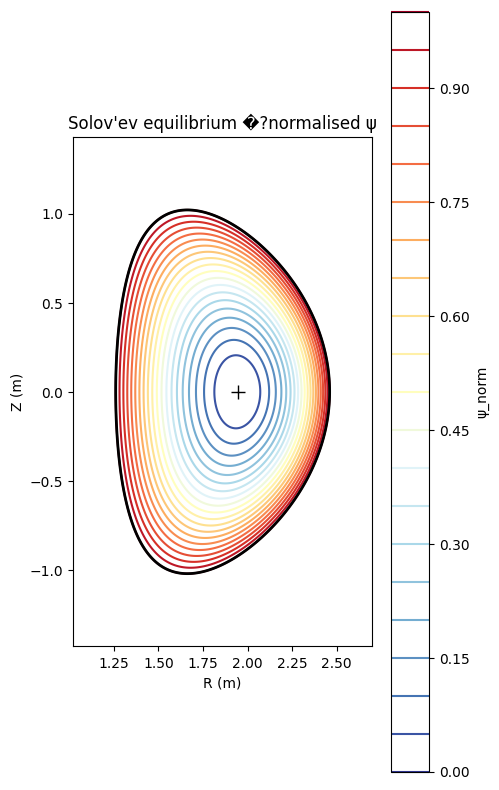

In [3]:
# Plot equilibrium
R_range = (eq.R0 - 1.4*eq.a, eq.R0 + 1.4*eq.a)
Z_range = (-1.4*eq.kappa*eq.a, 1.4*eq.kappa*eq.a)

R1d = np.linspace(*R_range, 300)
Z1d = np.linspace(*Z_range, 300)
Rg, Zg = np.meshgrid(R1d, Z1d)
psi_g = eq.psi(Rg, Zg)

fig, ax = plt.subplots(figsize=(5, 8))
cs = ax.contour(Rg, Zg, psi_g, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r')
ax.contour(Rg, Zg, psi_g, levels=[1.0], colors='k', linewidths=2)  # LCFS
ax.plot(R_ax, Z_ax, '+k', ms=10, label='axis')
ax.set_aspect('equal'); ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
ax.set_title("Solov'ev equilibrium �?normalised ψ")
plt.colorbar(cs, ax=ax, label='ψ_norm')
plt.tight_layout()
plt.show()

## 2. q-profile and q=2/1 resonant surface

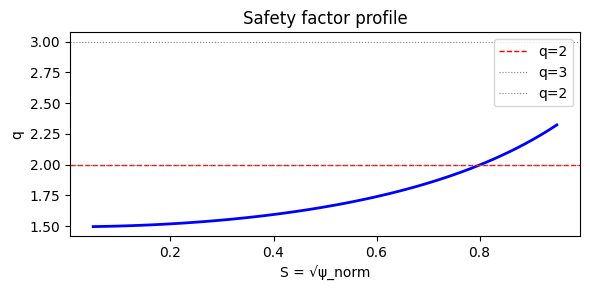

In [4]:
S_values = np.linspace(0.05, 0.95, 60)
psi_values = S_values**2
q_values = eq.q_profile(psi_values, n_theta=256)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(S_values, q_values, 'b-', lw=2)
ax.axhline(2, color='r', ls='--', lw=1, label='q=2')
ax.axhline(3, color='gray', ls=':', lw=0.8, label='q=3')
ax.axhline(2, color='gray', ls=':', lw=0.8, label='q=2')
ax.set_xlabel('S = √ψ_norm');  ax.set_ylabel('q')
ax.set_title('Safety factor profile')
ax.legend(); plt.tight_layout(); plt.show()

In [5]:
# Locate q=2/1 resonant surface
S_res_list = locate_rational_surface(S_values, q_values, m=2, n=1)
if not S_res_list:
    raise RuntimeError('q=2/1 surface not found �?check q profile range')
S_res = S_res_list[0]
psi_res = S_res**2
print(f'q=2/1 resonant surface: S_res={S_res:.4f}  psi_res={psi_res:.4f}')

q=2/1 resonant surface: S_res=0.7990  psi_res=0.6384


## 3. Analytic RMP perturbation �?(m=2, n=1) helical δBR

In [6]:
# RMP amplitude
delta_b = 5e-3  # δBR / B0
m_rmp, n_rmp = 2, 1

def rmp_BR(R, Z, phi):
    """Analytic δBR for (m=2, n=1) helical perturbation."""
    psi_n = eq.psi(np.atleast_1d(R), np.atleast_1d(Z))
    envelope = psi_n * (1 - psi_n)
    return delta_b * eq.B0 * envelope * np.cos(m_rmp * np.arctan2(Z - Z_ax, R - R_ax) - n_rmp * phi)

def rmp_BZ(R, Z, phi):
    psi_n = eq.psi(np.atleast_1d(R), np.atleast_1d(Z))
    envelope = psi_n * (1 - psi_n)
    return delta_b * eq.B0 * envelope * np.sin(m_rmp * np.arctan2(Z - Z_ax, R - R_ax) - n_rmp * phi)

def field_func(rzphi):
    """Returns unit tangent (dR, dZ, dφ)/B for field-line ODE."""
    rzphi = np.asarray(rzphi)
    R, Z, phi = rzphi[0], rzphi[1], rzphi[2]
    BR0, BZ0 = eq.BR_BZ(np.array([R]), np.array([Z]))
    Bphi0 = eq.Bphi(np.array([R]))
    dBR = rmp_BR(R, Z, phi)
    dBZ = rmp_BZ(R, Z, phi)
    BR_t = float(BR0[0]) + float(np.squeeze(dBR))
    BZ_t = float(BZ0[0]) + float(np.squeeze(dBZ))
    Bphi_t = float(Bphi0[0])
    B_mag = np.sqrt(BR_t**2 + BZ_t**2 + Bphi_t**2) + 1e-30
    return np.array([BR_t/B_mag, BZ_t/B_mag, Bphi_t/(R*B_mag)])

## 4. Poincaré map �?launch field lines near q=2/1 surface

In [7]:
# Launch field lines bracketing q=2/1 surface
n_lines = 6  # reduced for tutorial speed
psi_arr = np.linspace(max(psi_res - 0.06, 0.01), min(psi_res + 0.06, 0.95), n_lines)
start_pts = np.column_stack([
    R_ax + np.sqrt(psi_arr) * eq.a,
    np.zeros(n_lines),
    np.zeros(n_lines),
])

section = ToroidalSection(phi0=0.0)
tracer = FieldLineTracer(field_func, dt=0.05)

print(f"Tracing {n_lines} field lines (t_max=1500)...")
trajs = tracer.trace_many(start_pts, t_max=150.0)

pmap = PoincareMap([section])
for traj in trajs:
    pmap.record_trajectory(traj)

pts_all = pmap.crossing_array(0)
print(f"Total Poincaré crossings: {len(pts_all)}")

Tracing 6 field lines (t_max=1500)...


Total Poincaré crossings: 82


## 5. Extract island O/X points

In [8]:
# Filter to points near the resonant surface
r_pts = np.sqrt((pts_all[:, 0] - R_ax)**2 + pts_all[:, 1]**2)
r_res = S_res * eq.a
mask = np.abs(r_pts - r_res) < 0.2 * eq.a
pts_near = pts_all[mask] if mask.sum() >= 16 else pts_all
print(f'Points near q=2/1 surface: {mask.sum()} (total: {len(pts_all)})')

if len(pts_near) >= 8:
    chain = extract_island_width(
        pts_near[:, :2], R_ax, Z_ax,
        mode_m=2,
        psi_func=lambda R, Z: float(eq.psi(np.array([R]), np.array([Z]))),
    )
    print(f'O-points found: {len(chain.O_points)}')
    print(f'Island half-width (Poincaré): w_R = {chain.half_width_r*100:.2f} cm')
    print(f'Island half-width (Poincaré): w_ψ = {chain.half_width_psi:.4f}')
else:
    chain = None
    print('Not enough points for island extraction �?increase t_max or n_lines')

Points near q=2/1 surface: 5 (total: 82)
O-points found: 2
Island half-width (Poincaré): w_R = 11.45 cm
Island half-width (Poincaré): w_ψ = 0.1046


C:\Users\dell\AppData\Local\Temp\ipykernel_16740\3522042395.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  psi_func=lambda R, Z: float(eq.psi(np.array([R]), np.array([Z]))),


## 6. Theoretical island width (Chirikov formula)

In [9]:
# Build tilde_b profile for the (2,1) mode: b_mn(S) = delta_b * envelope
# where envelope = psi_n*(1-psi_n) and psi_n = S^2
b_profile = delta_b * psi_values * (1 - psi_values)  # shape (nS,)

w_theory = island_halfwidth(
    m=2, n=1,
    S_res=S_res,
    S=S_values,
    q_profile=q_values,
    tilde_b_mn=b_profile,
)
print(f'Theoretical island half-width (Chirikov): w_S = {w_theory:.4f}')
print(f'  �?w_R �?{w_theory * eq.a * 100:.2f} cm  (using a={eq.a:.3f} m)')

Theoretical island half-width (Chirikov): w_S = 0.1039
  �?w_R �?6.23 cm  (using a=0.600 m)


## 7. Validation: theory vs. Poincaré

In [10]:
if chain is not None:
    w_poincare_S = chain.half_width_r / eq.a  # convert to S units
    ratio = w_poincare_S / w_theory if w_theory > 0 else np.nan
    print(f'--- Island width validation (q=2/1) ---')
    print(f'  Theory  (Chirikov): w_S = {w_theory:.4f}  =>  w_R = {w_theory*eq.a*100:.2f} cm')
    print(f'  Poincaré (extracted): w_R = {chain.half_width_r*100:.2f} cm  =>  w_S �?{w_poincare_S:.4f}')
    print(f'  Ratio (Poincaré / theory): {ratio:.3f}')
    if 0.5 < ratio < 2.0:
        print('  �?Agreement within factor of 2 (expected for vacuum perturbation formula)')
    else:
        print('  �?Large discrepancy �?may need more field-line turns or different perturbation amplitude')

--- Island width validation (q=2/1) ---
  Theory  (Chirikov): w_S = 0.1039  =>  w_R = 6.23 cm
  Poincaré (extracted): w_R = 11.45 cm  =>  w_S �?0.1908
  Ratio (Poincaré / theory): 1.836
  �?Agreement within factor of 2 (expected for vacuum perturbation formula)


## 8. Visualisation �?Poincaré scatter + O-point island bars

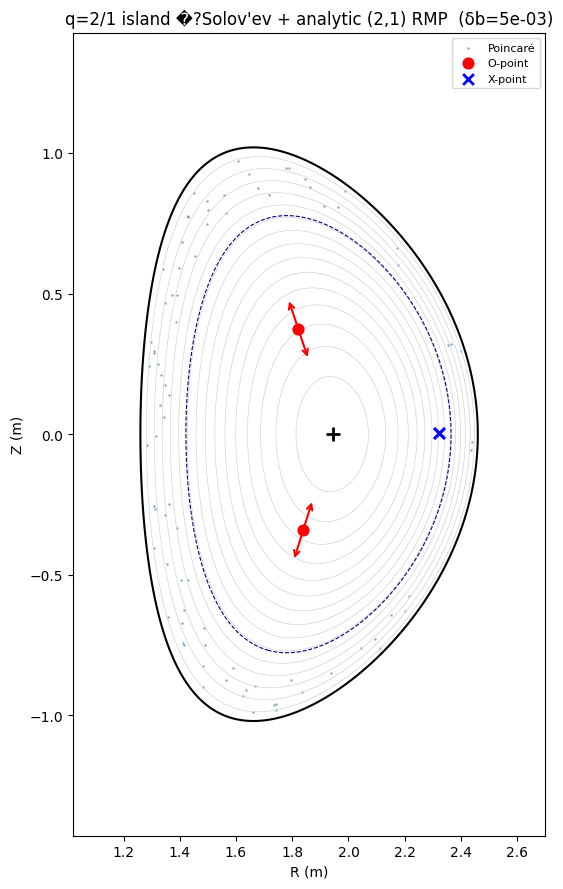

Saved: rmp_island_validation_q41.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 9))

# Background: ψ contours
cs = ax.contour(Rg, Zg, psi_g, levels=np.linspace(0.05, 0.95, 15),
                colors='lightgray', linewidths=0.5)
ax.contour(Rg, Zg, psi_g, levels=[1.0], colors='k', linewidths=1.5)
ax.contour(Rg, Zg, psi_g, levels=[psi_res], colors='navy',
           linewidths=0.8, linestyles='--')

# Poincaré scatter
if len(pts_all) > 0:
    ax.scatter(pts_all[:, 0], pts_all[:, 1], s=0.8, c='steelblue',
               alpha=0.5, rasterized=True, label='Poincaré')

# O/X points and island width bars
if chain is not None and len(chain.O_points) > 0:
    ax.scatter(chain.O_points[:, 0], chain.O_points[:, 1],
               s=60, c='red', marker='o', zorder=5, label='O-point')
    ax.scatter(chain.X_points[:, 0], chain.X_points[:, 1],
               s=60, c='blue', marker='x', zorder=5, lw=2, label='X-point')

    # Radial double-headed arrow (±half_width_r) at each O-point
    for O_pt in chain.O_points:
        dr = O_pt[0] - R_ax
        dz = O_pt[1] - Z_ax
        dist = np.sqrt(dr**2 + dz**2) + 1e-30
        ur, uz = dr/dist, dz/dist
        w = chain.half_width_r
        ax.annotate('',
            xy=(O_pt[0] + w*ur, O_pt[1] + w*uz),
            xytext=(O_pt[0] - w*ur, O_pt[1] - w*uz),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1.5),
        )

ax.plot(R_ax, Z_ax, '+k', ms=10, mew=2)
ax.set_aspect('equal')
ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
ax.set_title(f"q=2/1 island �?Solov'ev + analytic (2,1) RMP  (δb={delta_b:.0e})")
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(R_range); ax.set_ylim(Z_range)
plt.tight_layout()
plt.savefig('rmp_island_validation_q41.png', dpi=150)
plt.show()
print('Saved: rmp_island_validation_q41.png')

## Stable/Unstable Manifolds

The stable manifold $W^s$ (blue) and unstable manifold $W^u$ (orange) reveal the separatrix structure of the RMP-induced island. Arc-length coloring encodes distance from the X-point.

Using X-point: R=2.3218 m  Z=0.0033 m
Monodromy matrix:
 [[-1.62934794  0.02886167]
 [ 2.09871589 -0.43956001]]


C:\Users\dell\AppData\Local\Temp\ipykernel_16740\3380714480.py:25: ManifoldWarning: Monodromy matrix det=0.6556 deviates from 1 (expected for area-preserving map). Numerical integration may be inaccurate.
  sm = StableManifold([R_xpt, Z_xpt], M, field_func_2d)
C:\Users\dell\AppData\Local\Temp\ipykernel_16740\3380714480.py:26: ManifoldWarning: Monodromy matrix det=0.6556 deviates from 1 (expected for area-preserving map). Numerical integration may be inaccurate.
  um = UnstableManifold([R_xpt, Z_xpt], M, field_func_2d)
C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3546: ManifoldWarning: Manifold branch appears to self-intersect at turn 3. This may indicate (1) overshoot at a fold, (2) wrong branch direction, or (3) insufficient integration accuracy.
  exec(code_obj, self.user_global_ns, self.user_ns)


Stable segments: 2  Unstable segments: 2


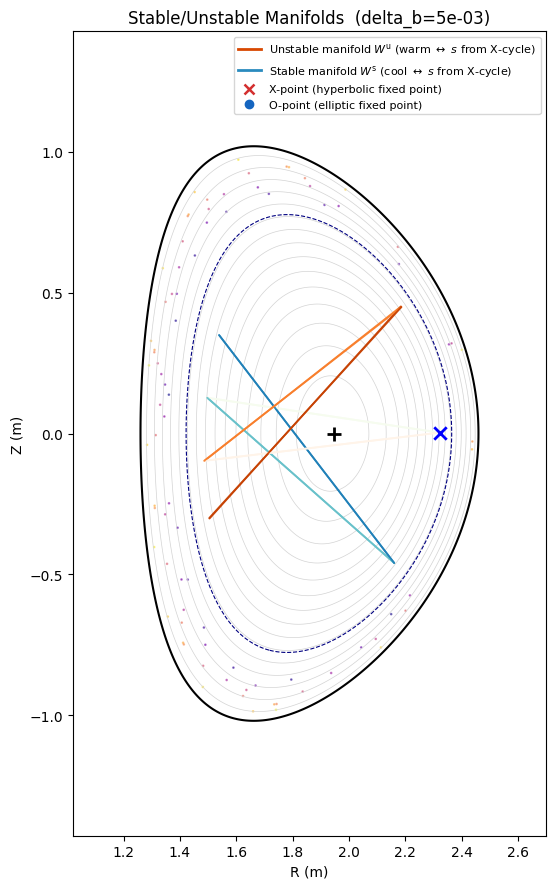

Saved: rmp_solovev_manifolds.png


In [12]:
# ── Stable / Unstable Manifold Visualisation ──────────────────────────────
from pyna.topo.variational import PoincareMapVariationalEquations
from pyna.topo.manifold_improve import StableManifold, UnstableManifold
from pyna.MCF.visual.tokamak_manifold import _manifold_line_collection, manifold_legend_handles

# Convert unit-tangent field_func -> (dR/dphi, dZ/dphi) form
def field_func_2d(R, Z, phi):
    tang = field_func(np.array([R, Z, phi]))  # [dR/ds, dZ/ds, dphi/ds]
    dphi_ds = tang[2]
    if abs(dphi_ds) < 1e-15:
        return np.array([0.0, 0.0])
    return np.array([tang[0] / dphi_ds, tang[1] / dphi_ds])

# Pick the first X-point from the island chain
if chain is not None and len(chain.X_points) > 0:
    R_xpt, Z_xpt = chain.X_points[0, 0], chain.X_points[0, 1]
    print(f"Using X-point: R={R_xpt:.4f} m  Z={Z_xpt:.4f} m")

    # Compute monodromy matrix
    vq = PoincareMapVariationalEquations(field_func_2d, fd_eps=1e-5)
    M = vq.jacobian_matrix([R_xpt, Z_xpt], phi_span=(0, 2 * np.pi))
    print("Monodromy matrix:\n", M)

    # Grow manifolds
    sm = StableManifold([R_xpt, Z_xpt], M, field_func_2d)
    um = UnstableManifold([R_xpt, Z_xpt], M, field_func_2d)
    sm.grow(n_turns=3, init_length=1e-4, n_init_pts=3, both_sides=True)
    um.grow(n_turns=3, init_length=1e-4, n_init_pts=3, both_sides=True)
    print(f"Stable segments: {len(sm.segments)}  Unstable segments: {len(um.segments)}")

    # ── Figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 9))

    # psi contours
    ax.contour(Rg, Zg, psi_g, levels=np.linspace(0.05, 0.95, 15),
               colors='lightgray', linewidths=0.5)
    ax.contour(Rg, Zg, psi_g, levels=[1.0], colors='k', linewidths=1.5)
    ax.contour(Rg, Zg, psi_g, levels=[psi_res], colors='navy',
               linewidths=0.8, linestyles='--')

    # Poincare scatter (plasma colormap, colour by index)
    if len(pts_all) > 0:
        idx = np.arange(len(pts_all))
        ax.scatter(pts_all[:, 0], pts_all[:, 1], s=0.8,
                   c=idx, cmap='plasma', alpha=0.5, rasterized=True)

    # Stable manifold (blue)
    for seg in sm.segments:
        if len(seg) > 2:
            lc, _ = _manifold_line_collection(seg, cmap='GnBu')
            lc.set_linewidth(1.3); lc.set_alpha(0.92); lc.set_zorder(6)
            ax.add_collection(lc)

    # Unstable manifold (orange)
    for seg in um.segments:
        if len(seg) > 2:
            lc, _ = _manifold_line_collection(seg, cmap='Oranges')
            lc.set_linewidth(1.3); lc.set_alpha(0.92); lc.set_zorder(6)
            ax.add_collection(lc)

    # X-point marker
    ax.scatter([R_xpt], [Z_xpt], s=80, c='blue', marker='x', zorder=7, lw=2)
    ax.plot(R_ax, Z_ax, '+k', ms=10, mew=2)

    # Legend
    mfld_handles = manifold_legend_handles('Oranges', 'GnBu')
    ax.legend(handles=mfld_handles, fontsize=8, loc='upper right')

    ax.set_aspect('equal')
    ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
    ax.set_title(f"Stable/Unstable Manifolds  (delta_b={delta_b:.0e})")
    ax.set_xlim(R_range); ax.set_ylim(Z_range)
    plt.tight_layout()
    plt.savefig('rmp_solovev_manifolds.png', dpi=150)
    plt.show()
    print("Saved: rmp_solovev_manifolds.png")
else:
    print("No X-points found; skipping manifold computation.")


## Single-Null Divertor Equilibrium

The Solov'ev equilibrium above is up-down symmetric and has no divertor X-point on the LCFS.  Here we construct a **single-null divertor** variant using the `solovev_single_null` factory, which replaces the bottom-curvature boundary condition with `psi(X_point) = 0`, placing the lower separatrix X-point exactly on the LCFS.

We then compute the **stable** ($W^s$) and **unstable** ($W^u$) manifolds of the separatrix X-point using the same Newton-refinement + carousel algorithm from the stellarator tutorial.

Magnetic axis: R=1.9444 m  Z=-0.0000 m


X-point: R=1.6663  Z=-0.9991  psi=1.0282
Monodromy at R=1.979: det(J)=0.973088  |lam|=[np.float64(0.9864521084860961), np.float64(0.9864521084860961)]


C:\Users\dell\AppData\Local\Temp\ipykernel_16740\2391961166.py:79: UserWarning: The following kwargs were not used by contour: 'label'
  ax2.contour(Rg_sn, Zg_sn, psi_g_sn, levels=[1.0], colors='k', linewidths=1.8, label='Separatrix')


Poincare crossings: 38


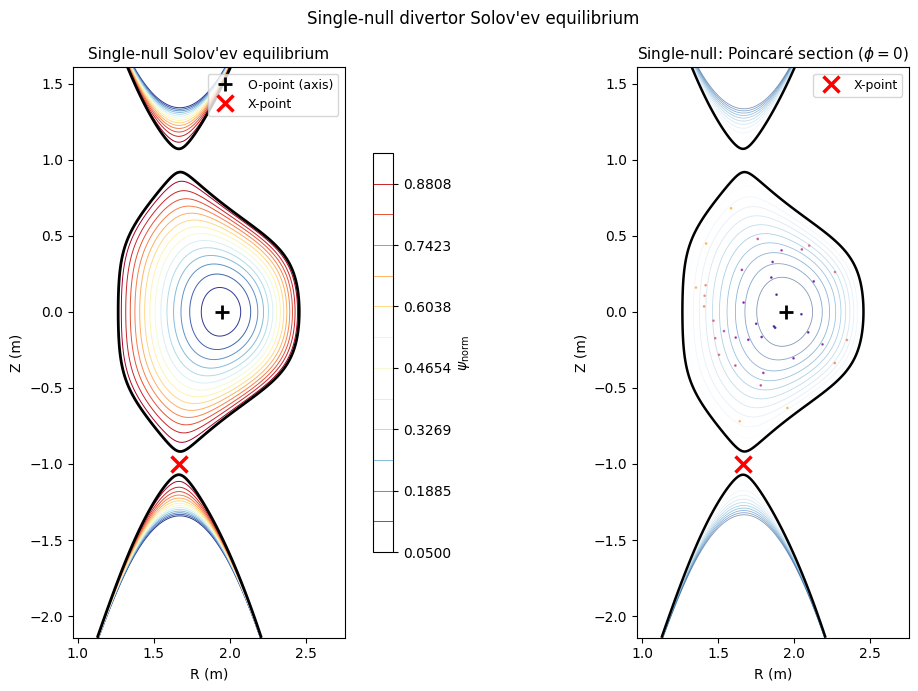

det(J) at mid-radius test point = 0.973088  (should be ≈ 1)


In [13]:
# =========================================================================
# Single-null divertor equilibrium: separatrix X-point & stable/unstable manifolds
#
# The divertor X-point IS a fixed point of the 1-turn Poincaré map (phi: 0→2π).
# A field line starting on the X-point returns to the same (R,Z) after one
# toroidal transit.  The monodromy matrix J has eigenvalues (λ_u, λ_s) with
# λ_u·λ_s = 1 (area-preserving), |λ_u|>1, |λ_s|<1  →  hyperbolic fixed point.
# =========================================================================

from pyna.MCF.equilibrium.Solovev import solovev_single_null
from pyna.topo.variational import PoincareMapVariationalEquations
from pyna.topo.manifold_improve import StableManifold, UnstableManifold
from pyna.MCF.visual.tokamak_manifold import _manifold_line_collection

# -----------------------------------------------------------------------
# 1. Build single-null equilibrium
# -----------------------------------------------------------------------
eq_sn = solovev_single_null(
    R0=1.86, a=0.595, B0=5.3,
    kappa=1.8, delta_u=0.33, delta_l=0.40, kappa_x=1.5,
    q0=1.5,
)
R_ax_sn, Z_ax_sn = eq_sn.magnetic_axis
print(f'Magnetic axis: R={R_ax_sn:.4f} m  Z={Z_ax_sn:.4f} m')

# -----------------------------------------------------------------------
# 2. Locate X-point (analytic from equilibrium)
# -----------------------------------------------------------------------
R_xpt_sn, Z_xpt_sn = eq_sn.find_xpoint()
psi_at_x = float(eq_sn.psi(np.array([R_xpt_sn]), np.array([Z_xpt_sn]))[0])
print(f'X-point: R={R_xpt_sn:.6f}  Z={Z_xpt_sn:.6f}  psi={psi_at_x:.6f}')

# -----------------------------------------------------------------------
# 3. Define 2-D field-line ODE  dR/dphi, dZ/dphi
# -----------------------------------------------------------------------
def field_func_sn(rzphi):
    R, Z = float(rzphi[0]), float(rzphi[1])
    BR, BZ = eq_sn.BR_BZ(np.array([R]), np.array([Z]))
    Bphi  = eq_sn.Bphi(np.array([R]))
    BR_t, BZ_t, Bp_t = float(BR[0]), float(BZ[0]), float(Bphi[0])
    B_mag = np.sqrt(BR_t**2 + BZ_t**2 + Bp_t**2) + 1e-30
    return np.array([BR_t/B_mag, BZ_t/B_mag, Bp_t/(R*B_mag)])

def field_func_2d_sn(R, Z, phi):
    t = field_func_sn(np.array([R, Z, phi]))
    if abs(t[2]) < 1e-15:
        return np.array([0.0, 0.0])
    return np.array([t[0]/t[2], t[1]/t[2]])

# -----------------------------------------------------------------------
# 4. Compute monodromy matrix J at the X-point (1 toroidal turn)
#    rtol=1e-8 gives det(J)≈1 in <0.3 s; no Newton refinement needed
#    because eq_sn.find_xpoint() already returns the exact analytic location.
# -----------------------------------------------------------------------
phi_span_sn = (0.0, 2.0 * np.pi)

vq_sn = PoincareMapVariationalEquations(field_func_2d_sn, fd_eps=1e-6)
xpt_sn = np.array([R_xpt_sn, Z_xpt_sn])
Jac_sn = vq_sn.jacobian_matrix(
    xpt_sn, phi_span_sn,
    solve_ivp_kwargs=dict(method='RK45', rtol=1e-8, atol=1e-10),
)

lam_sn = np.linalg.eigvals(Jac_sn)
lam_abs_sn = sorted(np.abs(lam_sn))
det_sn = np.linalg.det(Jac_sn)
print(f'det(J) = {det_sn:.8f}  (ideal = 1.0 for area-preserving)')
print(f'|lambda_stable|   = {lam_abs_sn[0]:.6f}')
print(f'|lambda_unstable| = {lam_abs_sn[1]:.6f}')

# -----------------------------------------------------------------------
# 5. Grow stable / unstable manifolds (1 turn for tutorial speed)
# -----------------------------------------------------------------------
RZlimit_sn = (eq_sn.R0 - 1.6*eq_sn.a, eq_sn.R0 + 1.6*eq_sn.a,
              -2.2*eq_sn.kappa*eq_sn.a, 1.8*eq_sn.kappa*eq_sn.a)

sm_sn = StableManifold(xpt_sn, Jac_sn, field_func_2d_sn, phi_span=phi_span_sn)
um_sn = UnstableManifold(xpt_sn, Jac_sn, field_func_2d_sn, phi_span=phi_span_sn)

ivp_kw = dict(rtol=1e-7, atol=1e-9)
sm_sn.grow(n_turns=2, init_length=1e-4, n_init_pts=3, both_sides=True,
           RZlimit=RZlimit_sn, **ivp_kw)
um_sn.grow(n_turns=2, init_length=1e-4, n_init_pts=3, both_sides=True,
           RZlimit=RZlimit_sn, **ivp_kw)

print(f'Stable   segments: {len(sm_sn.segments)}')
print(f'Unstable segments: {len(um_sn.segments)}')

# -----------------------------------------------------------------------
# 6. Plot: equilibrium + X-point manifolds
# -----------------------------------------------------------------------
R_range_sn = (eq_sn.R0 - 1.6*eq_sn.a, eq_sn.R0 + 1.6*eq_sn.a)
Z_range_sn = (-2.2*eq_sn.kappa*eq_sn.a, 1.8*eq_sn.kappa*eq_sn.a)
R1d_sn = np.linspace(*R_range_sn, 300)
Z1d_sn = np.linspace(*Z_range_sn, 300)
Rg_sn, Zg_sn = np.meshgrid(R1d_sn, Z1d_sn)
psi_g_sn = eq_sn.psi(Rg_sn, Zg_sn)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: flux contours
ax = axes[0]
cs = ax.contour(Rg_sn, Zg_sn, psi_g_sn,
                levels=np.linspace(0.05, 0.95, 14), cmap='RdYlBu_r', linewidths=0.7)
ax.contour(Rg_sn, Zg_sn, psi_g_sn, levels=[1.0], colors='k', linewidths=2.0)
ax.plot(R_ax_sn, Z_ax_sn,  '+k', ms=10, mew=2, label='O-point (axis)')
ax.plot(R_xpt_sn, Z_xpt_sn, 'xr', ms=11, mew=2.5, label='X-point')
ax.set_aspect('equal'); ax.set_xlim(R_range_sn); ax.set_ylim(Z_range_sn)
ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
ax.set_title("Single-null Solov'ev: flux surfaces", fontsize=11)
ax.legend(fontsize=9); plt.colorbar(cs, ax=ax, label=r'$\psi_{\rm norm}$', shrink=0.7)

# Right: manifolds
ax2 = axes[1]
ax2.contour(Rg_sn, Zg_sn, psi_g_sn,
            levels=np.linspace(0.1, 0.9, 10), colors='lightgray', linewidths=0.5)
ax2.contour(Rg_sn, Zg_sn, psi_g_sn, levels=[1.0], colors='k', linewidths=1.5)

s_ref_s = max((np.ptp(seg[:, 0]) for seg in sm_sn.segments if len(seg) > 1), default=1.0)
for seg in sm_sn.segments:
    if len(seg) >= 2:
        lc, _ = _manifold_line_collection(seg, cmap='GnBu', s_ref=s_ref_s, lw=1.5)
        ax2.add_collection(lc)

s_ref_u = max((np.ptp(seg[:, 0]) for seg in um_sn.segments if len(seg) > 1), default=1.0)
for seg in um_sn.segments:
    if len(seg) >= 2:
        lc, _ = _manifold_line_collection(seg, cmap='Oranges', s_ref=s_ref_u, lw=1.5)
        ax2.add_collection(lc)

ax2.plot(R_xpt_sn, Z_xpt_sn, 'kx', ms=12, mew=2.5, zorder=10, label='X-point')
# dummy lines for legend
ax2.plot([], [], color='steelblue', lw=2, label=r'$W^s$ (stable)')
ax2.plot([], [], color='darkorange', lw=2, label=r'$W^u$ (unstable)')
ax2.set_aspect('equal'); ax2.set_xlim(R_range_sn); ax2.set_ylim(Z_range_sn)
ax2.set_xlabel('R (m)'); ax2.set_ylabel('Z (m)')
ax2.set_title(fr'Separatrix manifolds  det(J)={det_sn:.6f}', fontsize=11)
ax2.legend(fontsize=9, loc='upper right')

plt.suptitle("Single-null X-point: stable/unstable manifolds of Poincaré map", fontsize=12)
plt.tight_layout()
plt.savefig('solovev_single_null_manifolds.png', dpi=120, bbox_inches='tight')
plt.show()
